Notebook 02 - Exploratory Data Analysis (EDA)
NLP Assignment - Fake News Detection
Person 3: N.A.Matheesha Desaman (CIT-24-01-0435)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("✅ Libraries imported!")

✅ Libraries imported!


In [2]:
df = pd.read_csv('../data/welFake_cleaned.csv')
print("Shape:", df.shape)
df.head()

Shape: (72095, 2)


,final_text,label
0,law enforcement high alert following threat co...,1
1,post vote hillary already,1
2,unbelievable obamas attorney general say charl...,1
3,bobby jindal raised hindu us story christian c...,0
4,satan russia unvelis image terrifying new supe...,1


## 1. Class Distribution

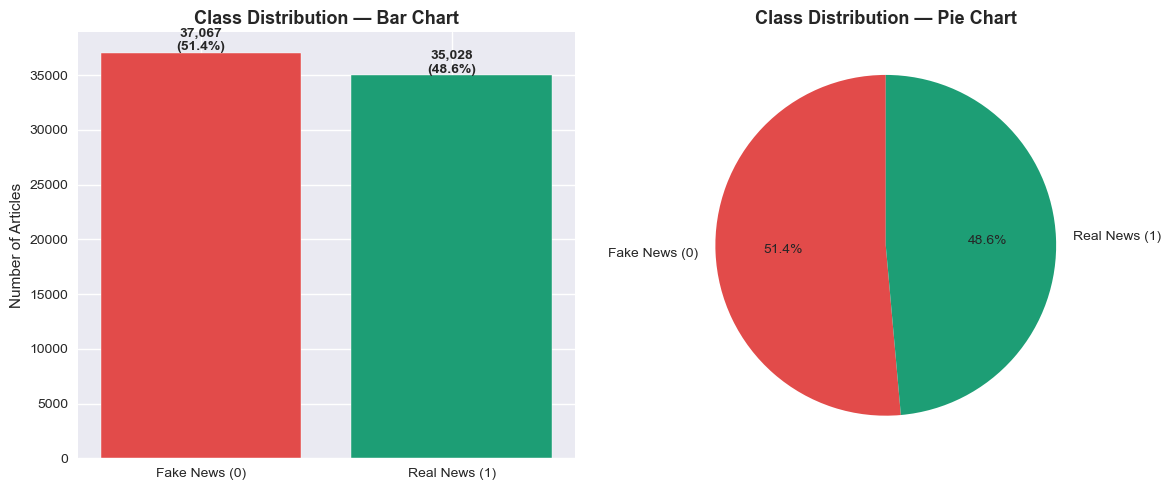

✅ Chart saved!


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#E24B4A', '#1D9E75']
counts = df['label'].value_counts()
labels = ['Fake News (0)', 'Real News (1)']

axes[0].bar(labels, counts.values, color=colors, edgecolor='white')
axes[0].set_title('Class Distribution — Bar Chart', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Articles')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution — Pie Chart', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../screenshots/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

## 2. Article Length Analysis

Fake news avg length: 336 words
Real news avg length: 286 words


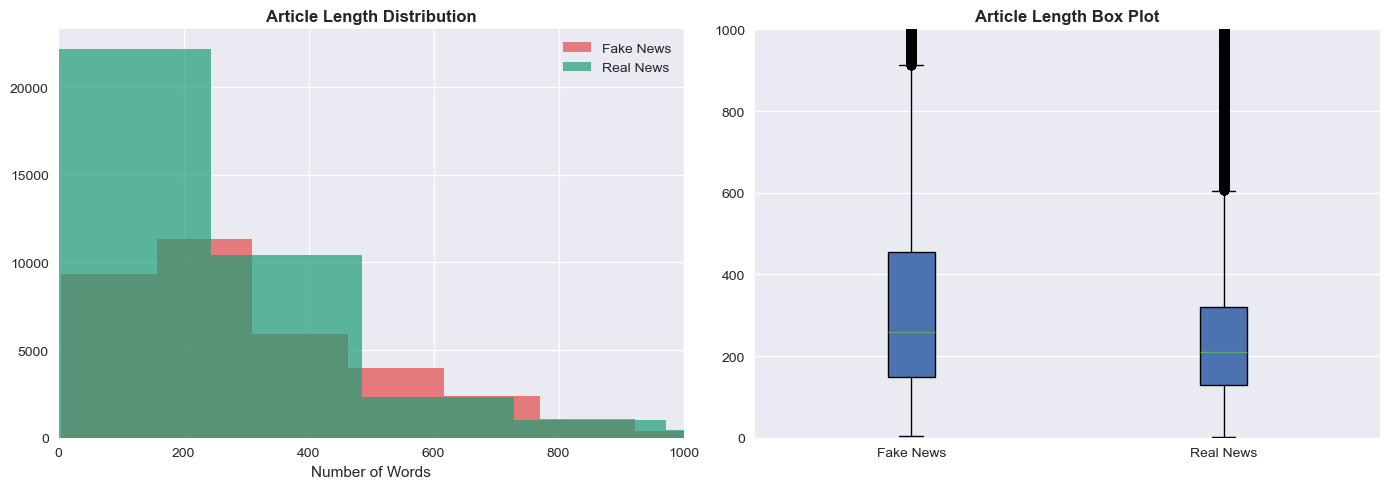

In [4]:
df['text_length'] = df['final_text'].apply(lambda x: len(str(x).split()))

fake = df[df['label'] == 0]['text_length']
real = df[df['label'] == 1]['text_length']

print(f"Fake news avg length: {fake.mean():.0f} words")
print(f"Real news avg length: {real.mean():.0f} words")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(fake, bins=50, alpha=0.7, color='#E24B4A', label='Fake News')
axes[0].hist(real, bins=50, alpha=0.7, color='#1D9E75', label='Real News')
axes[0].set_title('Article Length Distribution', fontweight='bold')
axes[0].set_xlabel('Number of Words')
axes[0].legend()
axes[0].set_xlim(0, 1000)

axes[1].boxplot([fake, real], labels=['Fake News', 'Real News'], patch_artist=True)
axes[1].set_title('Article Length Box Plot', fontweight='bold')
axes[1].set_ylim(0, 1000)

plt.tight_layout()
plt.savefig('../screenshots/02_article_length.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Word Frequency Analysis

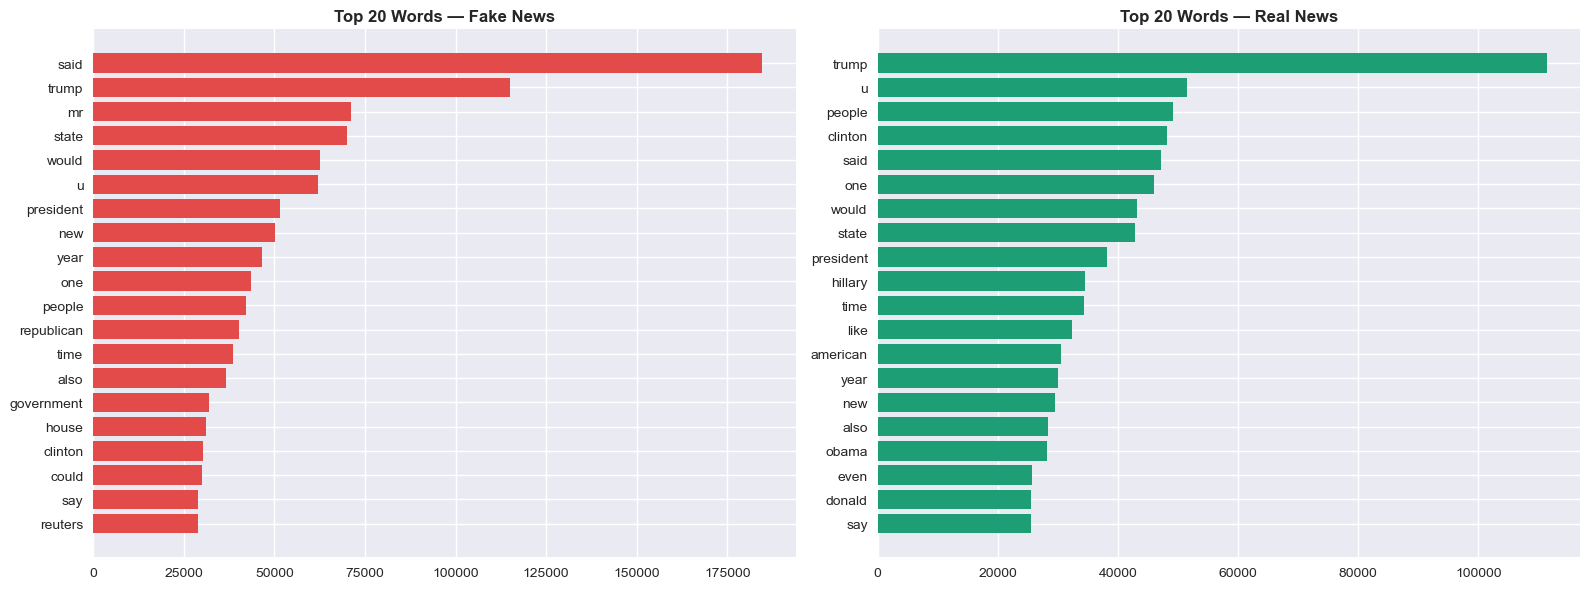

In [5]:
def get_top_words(data, n=20):
    all_words = ' '.join(data.dropna().astype(str)).split()
    return Counter(all_words).most_common(n)

fake_words = get_top_words(df[df['label'] == 0]['final_text'])
real_words  = get_top_words(df[df['label'] == 1]['final_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

words_f, counts_f = zip(*fake_words)
axes[0].barh(list(reversed(words_f)), list(reversed(counts_f)), color='#E24B4A')
axes[0].set_title('Top 20 Words — Fake News', fontweight='bold')

words_r, counts_r = zip(*real_words)
axes[1].barh(list(reversed(words_r)), list(reversed(counts_r)), color='#1D9E75')
axes[1].set_title('Top 20 Words — Real News', fontweight='bold')

plt.tight_layout()
plt.savefig('../screenshots/03_word_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

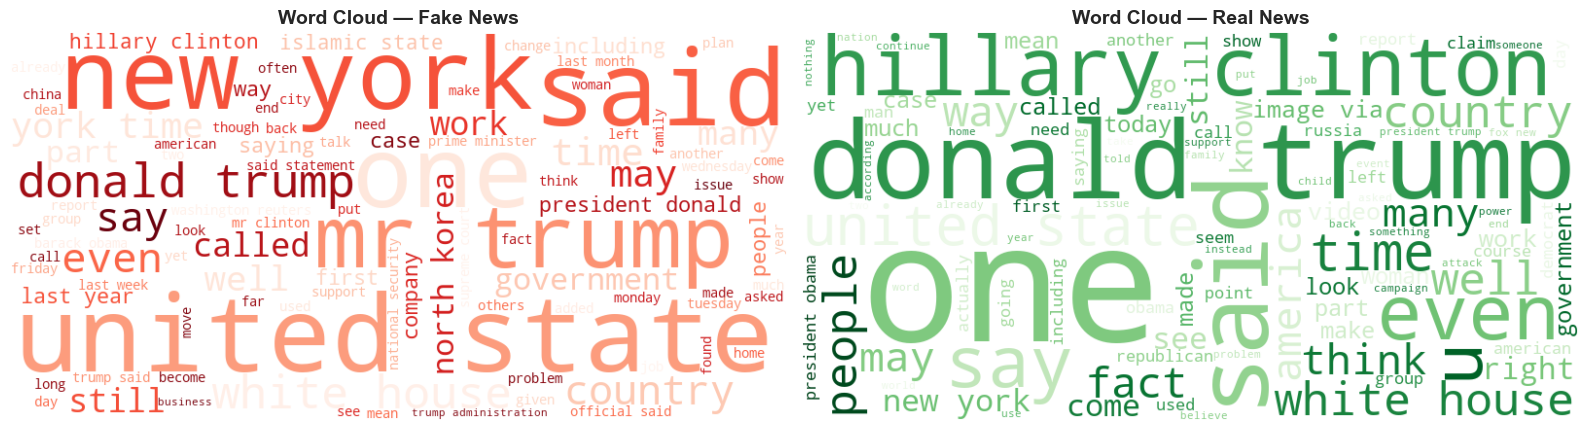

In [6]:
fake_text = ' '.join(df[df['label'] == 0]['final_text'].dropna())
real_text  = ' '.join(df[df['label'] == 1]['final_text'].dropna())

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

wc_fake = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=100).generate(fake_text)
axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud — Fake News', fontsize=14, fontweight='bold')

wc_real = WordCloud(width=800, height=400, background_color='white', colormap='Greens', max_words=100).generate(real_text)
axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud — Real News', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../screenshots/04_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Key Insights
1. **Class Balance:** Dataset is roughly balanced — good for Naive Bayes and BERT.
2. **Article Length:** Real news tends to be longer and more detailed.
3. **Word Patterns:** Fake news uses more emotionally charged, sensational words.
4. **BERT Advantage:** Because BERT reads context (not just word frequency), it can
   catch subtle fake news patterns that simpler models miss.